In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.15.0


In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


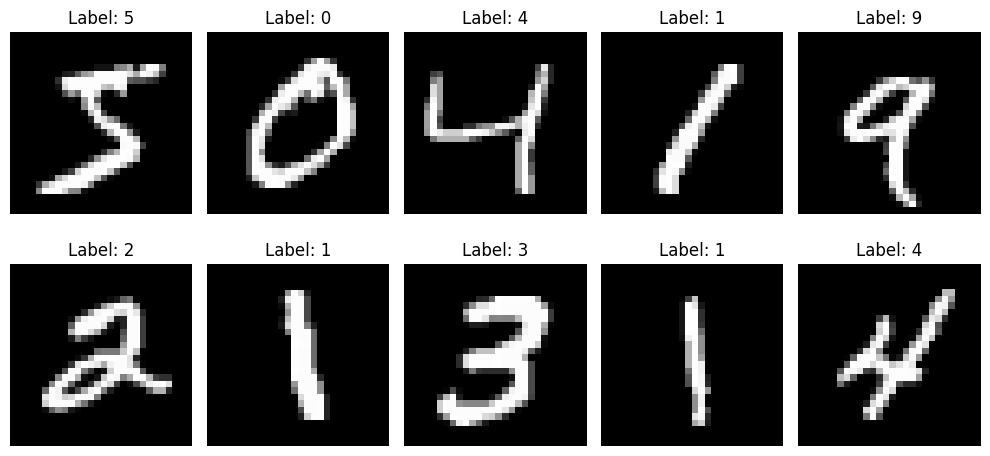

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [6]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)              

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")


Model compiled successfully!


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5


844/844 [==============================] - 76s 85ms/step - loss: 0.1728 - accuracy: 0.9475 - val_loss: 0.0539 - val_accuracy: 0.9852
Epoch 2/5
844/844 [==============================] - 70s 83ms/step - loss: 0.0499 - accuracy: 0.9848 - val_loss: 0.0438 - val_accuracy: 0.9880
Epoch 3/5
844/844 [==============================] - 56s 66ms/step - loss: 0.0346 - accuracy: 0.9887 - val_loss: 0.0346 - val_accuracy: 0.9902
Epoch 4/5
844/844 [==============================] - 57s 67ms/step - loss: 0.0251 - accuracy: 0.9920 - val_loss: 0.0502 - val_accuracy: 0.9857
Epoch 5/5
844/844 [==============================] - 57s 67ms/step - loss: 0.0193 - accuracy: 0.9934 - val_loss: 0.0308 - val_accuracy: 0.9912


In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 [==============================] - 4s 13ms/step - loss: 0.0303 - accuracy: 0.9902
Test Loss: 0.030339770019054413
Test Accuracy: 0.9901999831199646


In [10]:
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 99.02%


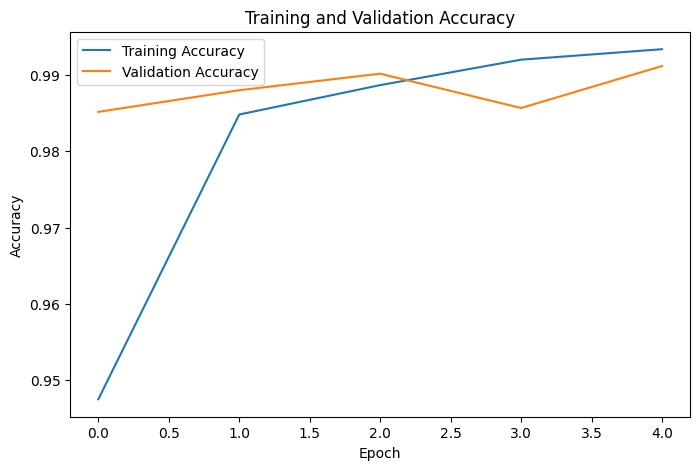

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

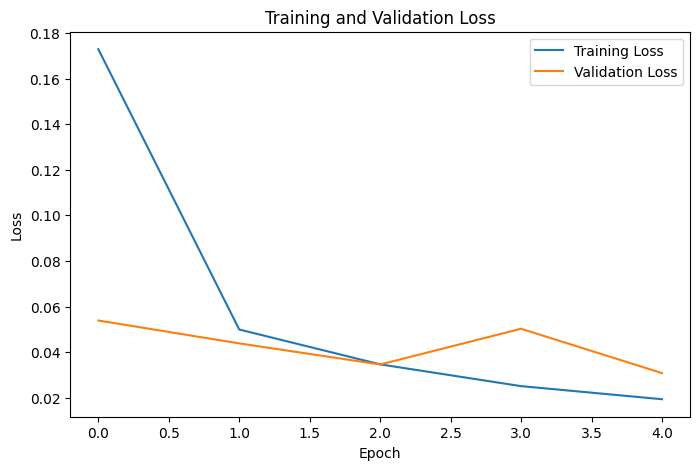

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 [==============================] - 0s 257ms/step


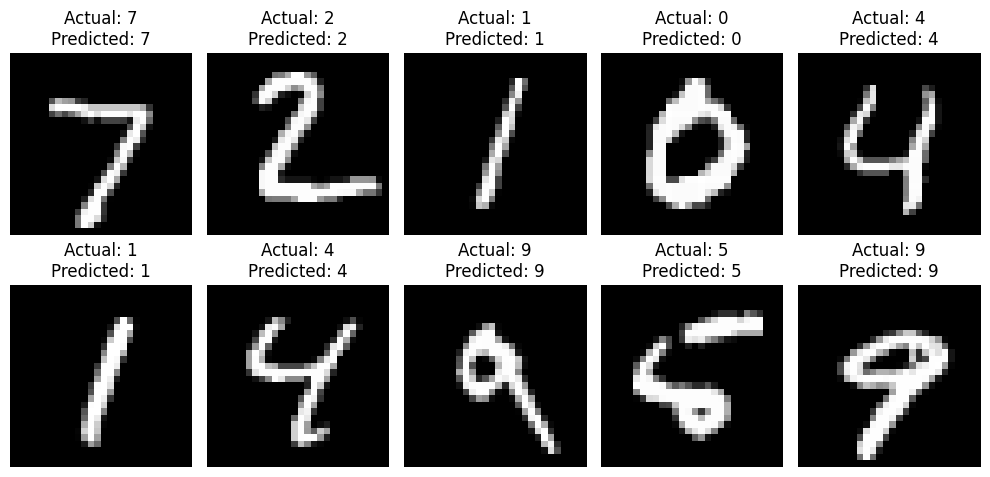

In [13]:
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(X_test[:10])

predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

313/313 [==============================] - 4s 14ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



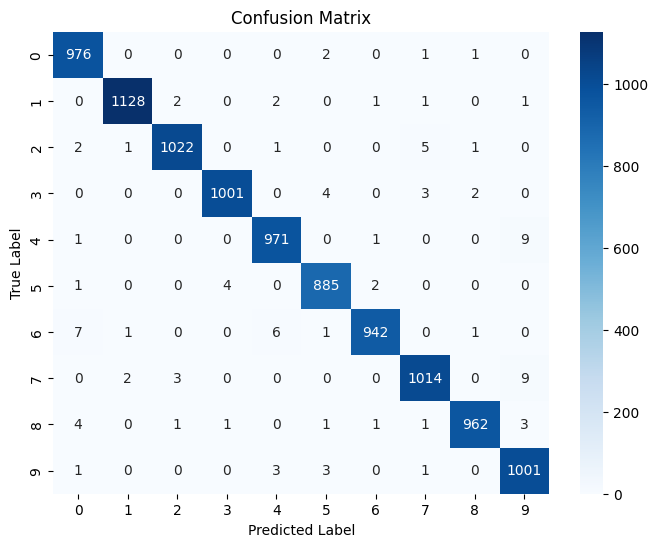

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [16]:
model.save("handwritten_character_recognition.keras")

print("Model saved successfully!")

Model saved successfully!


1/1 [==============================] - 0s 103ms/step


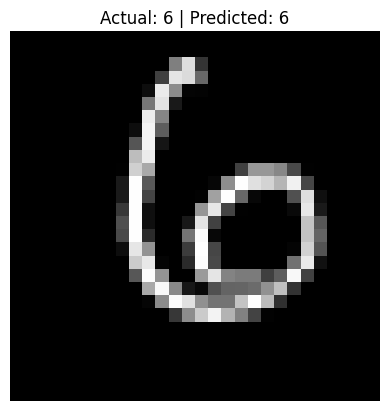

In [17]:
index = 100

image = X_test[index]

prediction = model.predict(image.reshape(1, 28, 28, 1))
predicted_digit = np.argmax(prediction)

plt.imshow(image.reshape(28, 28), cmap="gray")
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_digit}")
plt.axis("off")
plt.show()

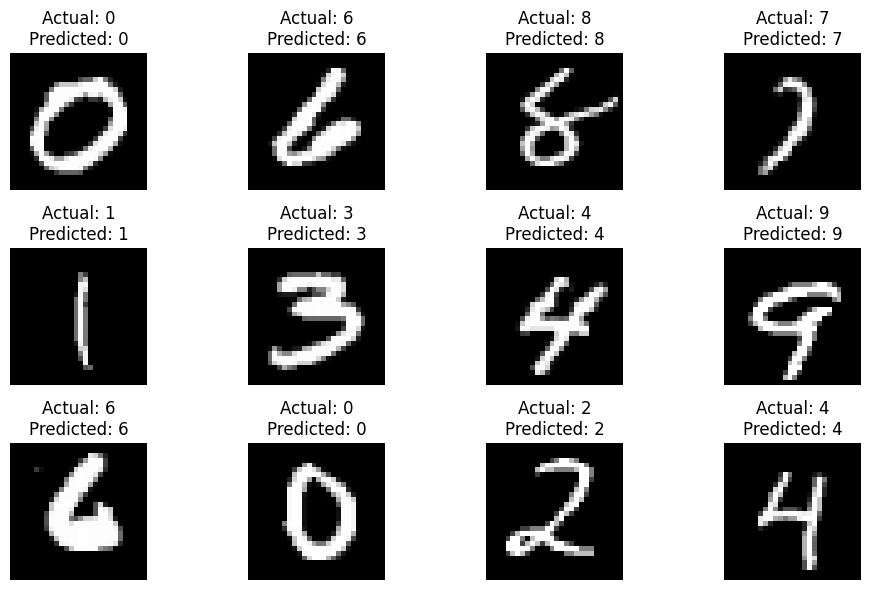

In [18]:
import random

plt.figure(figsize=(10, 6))

for i in range(12):
    index = random.randint(0, len(X_test) - 1)
    
    image = X_test[index]
    prediction = model.predict(image.reshape(1, 28, 28, 1), verbose=0)
    predicted_digit = np.argmax(prediction)
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.title(f"Actual: {y_test[index]}\nPredicted: {predicted_digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()